## Shapely Sandbox

Experiments with Shapely (Python library for geometry) and GeoPandas (Pandas functions that apply Shapely functions to data frames).

In [1]:
import geopandas as gp
import pandas as pd
from shapely.geometry import Point, LineString

from bokeh.palettes import Sunset10
from bokeh.io import output_notebook, show
from bokeh.plotting import figure

### Distance Between Two Points

In [2]:
p0 = Point(0,0)
p1 = Point(1,1)

In [3]:
(p0.x, p0.y)

(0.0, 0.0)

In [4]:
p0.distance(p1)

1.4142135623730951

In [5]:
Point.distance(p0,p1)

1.4142135623730951

### Distance from a Point to a Line Segment

A LineString is defined by a list of points.  Our segments will have just a starting and ending point.

In [6]:
seg = LineString([(0,0), (2,0)])

Create a line segment that connects the two points defined above.

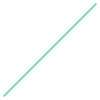

In [7]:
LineString([p0,p1])

Various ways to call the `distance` method to compute the distance between a point and a line segment:

In [8]:
seg.distance(Point(0,1))

1.0

In [9]:
seg.distance(Point(1,1))

1.0

In [10]:
seg.distance(Point(5,1))

3.1622776601683795

In [11]:
LineString.distance(seg, Point(0,1))

1.0

In [12]:
Point.distance(Point(0,1), seg)

1.0

### Test Data

Define some points and line segments to test the perpendicular intersection calculations

In [13]:
pf = gp.GeoDataFrame({'nucleus': [
    Point(2,13),
    Point(3,13),
    Point(4,10),
    Point(5,10),
    Point(9,10),
    Point(12,13),
    Point(2,7),
    Point(5,2),
    Point(9,3),
    Point(12,7),
]}, geometry='nucleus')
pf['id'] = list(range(len(pf)))
pf

,nucleus,id
0,POINT (2 13),0
1,POINT (3 13),1
2,POINT (4 10),2
3,POINT (5 10),3
4,POINT (9 10),4
5,POINT (12 13),5
6,POINT (2 7),6
7,POINT (5 2),7
8,POINT (9 3),8
9,POINT (12 7),9


In [14]:
sf = gp.GeoDataFrame({'segment': [
    LineString([(2,10),(5,13)]),
    LineString([(9,13),(12,10)]),
    LineString([(2,2),(5,8)]),
    LineString([(9,8),(12,2)]),
]}, geometry='segment')
sf

,segment
0,"LINESTRING (2 10, 5 13)"
1,"LINESTRING (9 13, 12 10)"
2,"LINESTRING (2 2, 5 8)"
3,"LINESTRING (9 8, 12 2)"


### Equations for Lines

Extract the $x$ and $y$ coordinates of line end points

In [15]:
sf['xi'] = sf.segment.apply(lambda seg: seg.coords[0][0])
sf['yi'] = sf.segment.apply(lambda seg: seg.coords[0][1])
sf['xj'] = sf.segment.apply(lambda seg: seg.coords[1][0])
sf['yj'] = sf.segment.apply(lambda seg: seg.coords[1][1])
sf

,segment,xi,yi,xj,yj
0,"LINESTRING (2 10, 5 13)",2.0,10.0,5.0,13.0
1,"LINESTRING (9 13, 12 10)",9.0,13.0,12.0,10.0
2,"LINESTRING (2 2, 5 8)",2.0,2.0,5.0,8.0
3,"LINESTRING (9 8, 12 2)",9.0,8.0,12.0,2.0


Compute $A$, $B$, and $C$ such that $[0 = Ax + By + C]$

In [16]:
sf['A'] = ((sf.yj-sf.yi)/(sf.xj-sf.xi))
sf['B'] = -1
sf['C'] = sf.yi-sf.xi*sf.A
sf

,segment,xi,yi,xj,yj,A,B,C
0,"LINESTRING (2 10, 5 13)",2.0,10.0,5.0,13.0,1.0,-1,8.0
1,"LINESTRING (9 13, 12 10)",9.0,13.0,12.0,10.0,-1.0,-1,22.0
2,"LINESTRING (2 2, 5 8)",2.0,2.0,5.0,8.0,2.0,-1,-2.0
3,"LINESTRING (9 8, 12 2)",9.0,8.0,12.0,2.0,-2.0,-1,26.0


### Perpendicular Intersection

A function that computes the intersections of vectors drawn from a point to each segment.

In [17]:
# PRELIMINARY VERSION, COMPLETE VERSION IS BELOW

def pi(p: Point, segs: gp.GeoDataFrame):
    '''
    Determine the location where a point `p` intersects each line in `segs`.

    Arguments:
      p: the starting point
      segs: a frame that has the line segments and their equations

    Returns:
      a series containing a Point object for each intersection
    '''
    xp = (p.y - (-p.x/segs.A) - segs.C) / (segs.A - (-1/segs.A))
    yp = (-xp/segs.A) + p.y - (-p.x/segs.A)
    return gp.GeoSeries([Point(xp[i],yp[i]) for i in range(len(segs))])


In [18]:
pi(pf.nucleus[0], sf)

0    POINT (3.5 11.5)
1    POINT (5.5 16.5)
2    POINT (6.4 10.8)
3    POINT (5.6 14.8)
dtype: geometry

### Filter

Compute the distance between the midpoint and the two ends of the line segments.  A mapping is "well approximated" if both distances are less than the length of the segment.  This new version of the `pi` function returns a frame with the distance information added.

The names of the distance columns are of the form "dXY" where X and Y are one-letter abbreviations of points:
  * `n` is the nucleus
  * `s` is the start point of the line segment
  * `e` is the end point of the nucleus
  * `m` is the midpoint (the location on the line between `s` and `e` where the line to `n` is perpendicular to the segment)

In [19]:
def pi(p: Point, segs: gp.GeoDataFrame):
    '''
    Determine the location where a point `p` intersects each line in `segs`.

    Arguments:
      p: the starting point
      segs: a frame that has the line segments and their equations

    Returns:
      a frame with intersection points and distances
    '''
    xp = (p.y - (-p.x/segs.A) - segs.C) / (segs.A - (-1/segs.A))
    yp = (-xp/segs.A) + p.y - (-p.x/segs.A)
    res = gp.GeoDataFrame({
        'nucleus': [p] * len(segs),
        'segment': segs.segment,
        'mid': [Point(xp[i],yp[i]) for i in range(len(segs))],
        # 'dse': [Point.distance(Point(s.coords[0]), Point(s.coords[1])) for s in segs.segment],
        'dse': segs.segment.length,
    }).set_geometry('nucleus').set_geometry('segment').set_geometry('mid')
    res['dsm'] = [Point.distance(res.mid[i], Point(res.segment[i].coords[0])) for i in range(len(segs))] 
    res['dme'] = [Point.distance(res.mid[i], Point(res.segment[i].coords[1])) for i in range(len(segs))] 
    res['dmd'] = [Point.distance(res.mid[i], p) for i in range(len(segs))] 
    res['accepted'] = (res.dsm < res.dse) & (res.dme < res.dse)
    return res

In [20]:
(pf.nucleus[0].x, pf.nucleus[0].y)

(2.0, 13.0)

In [21]:
sf

,segment,xi,yi,xj,yj,A,B,C
0,"LINESTRING (2 10, 5 13)",2.0,10.0,5.0,13.0,1.0,-1,8.0
1,"LINESTRING (9 13, 12 10)",9.0,13.0,12.0,10.0,-1.0,-1,22.0
2,"LINESTRING (2 2, 5 8)",2.0,2.0,5.0,8.0,2.0,-1,-2.0
3,"LINESTRING (9 8, 12 2)",9.0,8.0,12.0,2.0,-2.0,-1,26.0


In [22]:
pi(pf.nucleus[0], sf)

,nucleus,segment,mid,dse,dsm,dme,dmd,accepted
0,POINT (2 13),"LINESTRING (2 10, 5 13)",POINT (3.5 11.5),4.242641,2.121320,2.121320,2.121320,True
1,POINT (2 13),"LINESTRING (9 13, 12 10)",POINT (5.5 16.5),4.242641,4.949747,9.192388,4.949747,False
2,POINT (2 13),"LINESTRING (2 2, 5 8)",POINT (6.4 10.8),6.708204,9.838699,3.130495,4.919350,False
3,POINT (2 13),"LINESTRING (9 8, 12 2)",POINT (5.6 14.8),6.708204,7.602631,14.310835,4.024922,False


In [23]:
sf.segment.loc[0].length

4.242640687119285

### Plots

In [24]:
df = pi(pf.nucleus[0], sf)

In [25]:
output_notebook()

Loading BokehJS ...

In [26]:
p = figure(
    title='example', 
    x_axis_label='x', 
    y_axis_label='y',
    x_range=(0,20),
    y_range=(0,20),
    height=500,
    width=500,
    aspect_ratio=1)
nuc = df.nucleus[0]
for i, row in df.iterrows():
    x = [nuc.x, row.mid.x]
    y = [nuc.y, row.mid.y]
    p.line(x, y, line_width=1)
for i, row in df.iterrows():
    x = [row.segment.coords[0][0], row.mid.x]
    y = [row.segment.coords[0][1], row.mid.y]
    p.line(x, y, line_dash='dashed')
for i, row in df.iterrows():
    x = [row.segment.coords[i][0] for i in [0,1]]
    y = [row.segment.coords[i][1] for i in [0,1]]
    p.line(x,y,line_width=2)
p.scatter([nuc.x], [nuc.y], size=6)
# p.scatter(x='X', y='Y', size=5, source=mf)
# p.text(x='X', y='Y', text='Name', x_offset=5, y_offset=10, source=mf)
show(p)

### Law of Cosines 

Test data.  Define three triangles.  All have the same base (between (2,2) and (8.2)).  The top vertices are at (5,5), (8,5), and (11,5), which define scalene, right, and obtuse angles.

In [29]:
a = Point(2,2)
b = Point(8,2)
c = Point(5,5)
d = Point(8,5)
e = Point(11,5)

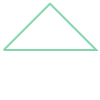

In [34]:
LineString([a,b,c,a])

In [88]:

from math import acos, pi, degrees

In [93]:
def angle(p, q, r):
    '''
    Use the law of cosines to compute the inner angles of a triangle with vertices at 
    points p, q, and r.
    '''
    def theta(a,b,c):
        return degrees(acos((a*a + b*b - c*c)/(2*a*b)))
    
    P = Point.distance(q,r)
    Q = Point.distance(p,r)
    R = Point.distance(p,q)

    scale = max(P,Q,R)
    px, qx, rx = P/scale, Q/scale, R/scale

    return theta(px,qx,rx), theta(rx,px,qx), theta(qx,rx,px)

In [94]:
angle(c,a,b)

(45.0, 45.0, 90.00000000000001)

In [95]:
angle(d,a,b)

(90.0, 26.565051177077994, 63.43494882292201)

In [96]:
angle(e,a,b)

(135.00000000000003, 18.434948822922017, 26.56505117707798)